# Financial Markets: Key Concepts with Python

This notebook covers essential topics in Financial Markets relevant to a Financial Engineering course. The focus will be on:

1. **Portfolio Theory**
2. **Risk Management**
3. **Derivatives Pricing**
4. **Market Analysis**

Each section includes theoretical background and corresponding Python code implementations.


## 1. Portfolio Theory

Modern Portfolio Theory (MPT), introduced by Harry Markowitz, aims to maximize expected portfolio return for a given amount of risk, or equivalently minimize risk for a given level of expected return.

Key concepts:
- Expected return
- Portfolio variance and standard deviation
- Efficient frontier
- Sharpe ratio


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

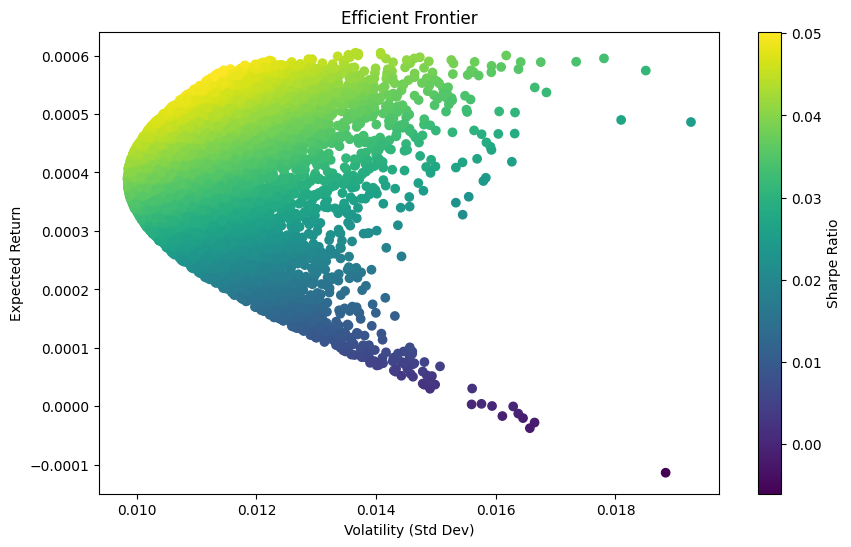

In [ ]:
# Simulated data for 4 assets
np.random.seed(42)
returns = np.random.randn(1000, 4) * 0.02
mean_returns = returns.mean(axis=0)
cov_matrix = np.cov(returns.T)

# Portfolio optimization
def portfolio_performance(weights, mean_returns, cov_matrix):
    returns = np.dot(weights, mean_returns)
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return returns, std

# Generate portfolios
results = []
for _ in range(10000):
    weights = np.random.random(4)
    weights /= np.sum(weights)
    ret, std = portfolio_performance(weights, mean_returns, cov_matrix)
    sharpe = ret / std
    results.append([ret, std, sharpe])

results = np.array(results)

# Plot efficient frontier
plt.figure(figsize=(10,6))
plt.scatter(results[:,1], results[:,0], c=results[:,2], cmap='viridis', marker='o')
plt.xlabel('Volatility (Std Dev)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.colorbar(label='Sharpe Ratio')
plt.show()

## 2. Risk Management

Risk management involves identifying and measuring risk, and deciding how to mitigate it.

Key concepts:
- Value at Risk (VaR)
- Conditional VaR (CVaR)
- Historical and Monte Carlo Simulation


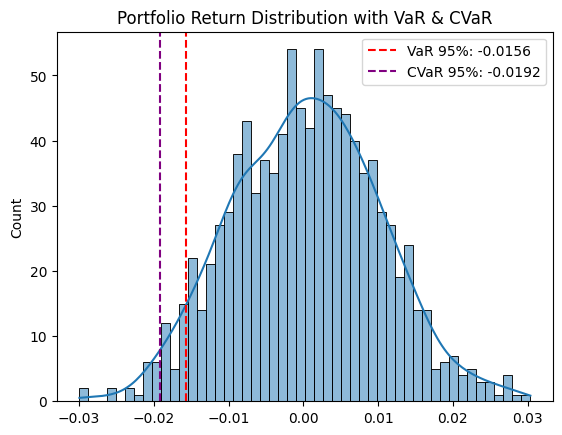

In [2]:
# Historical Value at Risk
import seaborn as sns

# Simulate portfolio returns
portfolio_returns = np.dot(returns, np.ones(4)/4)

# Historical VaR at 95% confidence
VaR_95 = np.percentile(portfolio_returns, 5)

# CVaR (Expected Shortfall)
CVaR_95 = portfolio_returns[portfolio_returns <= VaR_95].mean()

# Plotting
sns.histplot(portfolio_returns, bins=50, kde=True)
plt.axvline(VaR_95, color='red', linestyle='--', label=f'VaR 95%: {VaR_95:.4f}')
plt.axvline(CVaR_95, color='purple', linestyle='--', label=f'CVaR 95%: {CVaR_95:.4f}')
plt.title('Portfolio Return Distribution with VaR & CVaR')
plt.legend()
plt.show()

## 3. Derivatives Pricing

Derivative pricing includes models for valuing financial instruments like options.

Key concepts:
- Black-Scholes Model
- Greeks


In [3]:
from scipy.stats import norm
import math

# Black-Scholes Formula
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    return call_price

# Example
S = 100  # Stock price
K = 105  # Strike price
T = 1    # Time to maturity
r = 0.05 # Risk-free rate
sigma = 0.2  # Volatility

call_price = black_scholes_call(S, K, T, r, sigma)
print(f"Black-Scholes Call Option Price: {call_price:.2f}")

Black-Scholes Call Option Price: 8.02


## 4. Market Analysis

Market analysis uses historical data to forecast future movements.

Key concepts:
- Technical indicators: Moving Averages, RSI


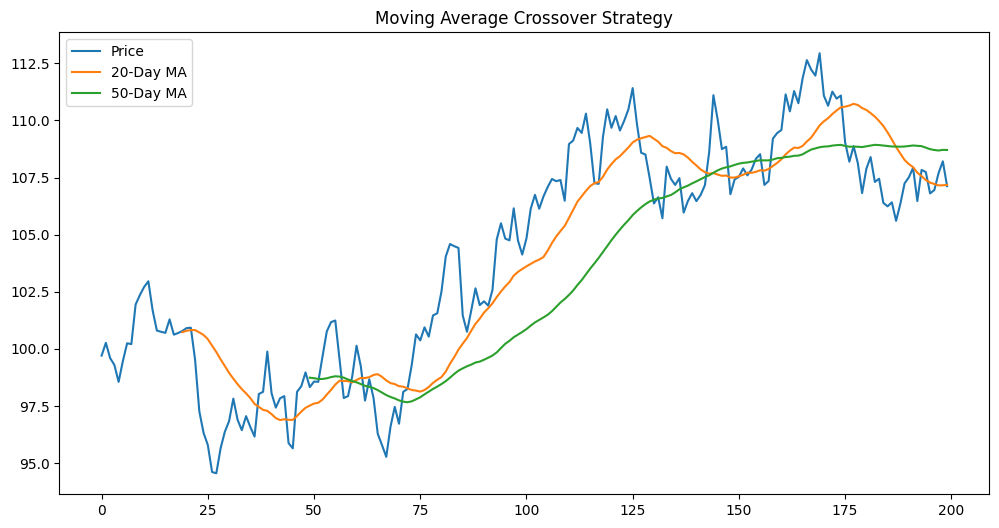

In [4]:
# Generate synthetic price series
price = 100 + np.cumsum(np.random.randn(200))

# Moving Averages
short_window = 20
long_window = 50

ma_short = pd.Series(price).rolling(window=short_window).mean()
ma_long = pd.Series(price).rolling(window=long_window).mean()

# Plotting
plt.figure(figsize=(12,6))
plt.plot(price, label='Price')
plt.plot(ma_short, label=f'{short_window}-Day MA')
plt.plot(ma_long, label=f'{long_window}-Day MA')
plt.title('Moving Average Crossover Strategy')
plt.legend()
plt.show()